# U.S. County-Level Obesity Trends and Socioeconomic Risk Factor Analysis

# Video Presentation

*   https://youtu.be/t3BWdGCif4M?si=699jRCZKTVSdpkKp


# Data Collection and Cleaning

## Downloaded Dataset Requirement



In [3]:
import pandas as pd
import numpy as np

def data_parser():

  # Read datasets
  df = pd.read_csv('StateAndCountyData.csv')

  # Inconsistency #1: Invalid or non-numeric values
  # Replacing missing or invalid values
  df.replace(['N/A', -9999, -8888], np.nan, inplace = True)
  df['Value'] = pd.to_numeric(df['Value'])

  # Variables we're using
  codes_to_keep = ['LACCESS_POP19', 'GROC20', 'FFR20', 'PCT_OBESE_ADULTS17', 'PCT_NHWHITE20']

  # Filter to only the rows with these variables
  df_filtered = df[df['Variable_Code'].isin(codes_to_keep)]

  # Drop duplicates and get unique counties
  df_main = df_filtered[['FIPS', 'State', 'County']].drop_duplicates().reset_index(drop = True)

  # Loop through the variable codes to turn into a column
  for code in codes_to_keep:

    # Getting data for just Variable_Code
    df_temp = df_filtered[df_filtered['Variable_Code'] == code]

    # Selecting columns we're using and Value
    df_temp_sub = df_temp[['FIPS', 'State', 'County', 'Value']].drop_duplicates()

    # Renaming value to the right variable
    df_temp = df_temp_sub.rename(columns = {'Value': code})

    # Merging the new column to the main DataFrame
    df_main = pd.merge(df_main, df_temp, on = ['FIPS', 'State', 'County'], how = 'left')

  # Renaming columns
  renamed = {'LACCESS_POP19':'Low_Access_Population', 'GROC20':'Grocery_Stores', 'FFR20':'Fast_Food_Rest_2020', 'PCT_OBESE_ADULTS17':'Adult_Obesity_Percent', 'PCT_NHWHITE20':'Percent_White_2020'}
  df_main.rename(columns = renamed, inplace = True)

  # Inconsistency #2: Round population counts
  # Store population data as an int and not a float
  if 'Low_Access_Population' in df_main.columns:
    df_main['Low_Access_Population'] = df_main['Low_Access_Population'].fillna(0)
    df_main['Low_Access_Population'] = df_main['Low_Access_Population'].round(0).astype(int)

  # Replacing NaN with mean of column
  df_main.fillna(df_main.mean(numeric_only=True), inplace=True)

  # Drop duplicates again in case
  df_main.drop_duplicates(inplace = True)

  # Export cleaned data to a new file
  df_main.to_csv('Cleaned_StateAndCountyData.csv', index = False)

  return df_main

############ Function Call ############
data_parser()

,FIPS,State,County,Low_Access_Population,Grocery_Stores,Fast_Food_Rest_2020,Adult_Obesity_Percent,Percent_White_2020
0,1001.0,AL,Autauga,18503,4.000000,45.000000,36.300000,70.711674
1,1003.0,AL,Baldwin,45789,29.000000,172.000000,36.300000,80.466589
2,1005.0,AL,Barbour,5634,5.000000,24.000000,36.300000,43.951949
3,1007.0,AL,Bibb,365,4.000000,7.000000,36.300000,73.754093
4,1009.0,AL,Blount,3902,4.000000,24.000000,36.300000,84.154632
...,...,...,...,...,...,...,...,...
3148,9150.0,CT,Northeastern Connecticut,0,27.312892,93.968937,31.863526,74.150915
3149,9160.0,CT,Northwest Hills,0,27.312892,93.968937,31.863526,74.150915
3150,9170.0,CT,South Central Connecticut,0,27.312892,93.968937,31.863526,74.150915
3151,9180.0,CT,Southeastern Connecticut,0,27.312892,93.968937,31.863526,74.150915


## Web Collection Requirement \#1


In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np


def web_parser1():

  url = 'https://en.wikipedia.org/wiki/Obesity_in_the_United_States'

  agent = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/97.0.4692.99 Safari/537.36"}

  response = requests.get(url, headers = agent)

  soup = BeautifulSoup(response.text, 'html.parser')

  # Finding the table
  table = soup.find('table', {'class':'wikitable sortable'})

  # Find all rows
  rows = table.find_all('tr')

  data = []

  # Looping through rows
  for row in rows[1:]:
    # Find all data cells in row
    cells = row.find_all('td')
    if len(cells) > 1:
      # The state is the first cell
      state = cells[0].get_text(strip = True)
      # The obesity is the 4th cell
      obesity = cells[3].get_text(strip = True)

      data.append([state, obesity])

  # Convert list to DataFrame
  df = pd.DataFrame(data, columns = ['State', 'Obesity_Percent'])

  # Data Cleaning
  # Remove citations [109] errored when testing so have to get rid of this
  df['Obesity_Percent'] = df['Obesity_Percent'].str.replace(r'\[.*?\]', '', regex = True)
  # Getting rid of em dash
  df['Obesity_Percent'] = df['Obesity_Percent'].str.replace('—', '')
  # Getting rid of %
  df['Obesity_Percent'] = df['Obesity_Percent'].str.replace('%', '')



  # Convert to number
  df['Obesity_Percent'] = pd.to_numeric(df['Obesity_Percent'])

  # Drop rows that don't have anything
  df.dropna(subset = ['Obesity_Percent'], inplace = True)

  # Save cleaned data
  df.to_csv('Cleaned_Wikipedia_Obesity.csv', index = False)

  return df

############ Function Call ############
web_parser1()

,State,Obesity_Percent
0,Alabama,36.3
1,Alaska,34.2
2,American Samoa,75.0
3,Arizona,29.5
4,Arkansas,35.0
5,California,25.1
6,Colorado,22.6
7,Connecticut,26.9
8,Delaware,31.8
9,District of Columbia,23.0


## Web Collection Requirement #2

In [5]:
import requests
import pandas as pd
import numpy as np

def web_parser2():

  # 2022 ACS 5-year estimates
  url = 'https://api.census.gov/data/2022/acs/acs5'

  # Asking for NAME and B19013_001E (var name for Median Household Income)
  what = 'NAME,B19013_001E'

  # Get all counties in all states
  where = 'for=county:*&in=state:*'

  api_url = f'{url}?get={what}&{where}'

  response = requests.get(api_url).json()

  # API returns a list of lists, first list = header, header now NAME, B19013_001E, state, and county
  df = pd.DataFrame(response[1:], columns = response[0])

  # Cleaning
  # Renaming Columns
  df.rename(columns = {'B19013_001E':'Median_Household_Income',
      'NAME':'County_Name',
      'state':'State'
  }, inplace = True)

  # FIPS = state code + county code
  df['FIPS'] = df['State'] + df['county']

  # Converting Datatypes
  df['Median_Household_Income'] = pd.to_numeric(df['Median_Household_Income'])
  df['FIPS'] = pd.to_numeric(df['FIPS'])

  # Missing or Invalid Data
  df.loc[df['Median_Household_Income'] <= 0, 'Median_Household_Income'] = np.nan

  # Dropping rows with no FIPS or no Income Data
  df.dropna(subset = ['FIPS', 'Median_Household_Income'], inplace = True)

  # Selecting columns we need
  df_cleaned = df[['FIPS', 'County_Name', 'State', 'Median_Household_Income']]

  df_cleaned.to_csv('Cleaned_Census_Income_Data.csv', index = False)

  return df_cleaned

############ Function Call ############
web_parser2()

,FIPS,County_Name,State,Median_Household_Income
0,1001,"Autauga County, Alabama",01,68315.0
1,1003,"Baldwin County, Alabama",01,71039.0
2,1005,"Barbour County, Alabama",01,39712.0
3,1007,"Bibb County, Alabama",01,50669.0
4,1009,"Blount County, Alabama",01,57440.0
...,...,...,...,...
3217,72145,"Vega Baja Municipio, Puerto Rico",72,23701.0
3218,72147,"Vieques Municipio, Puerto Rico",72,17062.0
3219,72149,"Villalba Municipio, Puerto Rico",72,22461.0
3220,72151,"Yabucoa Municipio, Puerto Rico",72,19972.0


## Data Sources
*   Downloaded Dataset Source: https://www.ers.usda.gov/data-products/food-environment-atlas/data-access-and-documentation-downloads
*   Web Collection #1 Source: https://en.wikipedia.org/wiki/Obesity_in_the_United_States
*   Web Collection #2 Source: https://api.census.gov/data/2022/acs/acs5




# Data Analysis

# Topic Summary

This notebook contains a data analysis project exploring the relationship between socioeconomic risk factors and public health outcomes across US counties. Built in Python using Pandas, the scripts clean and merge demographic data from the US Census with USDA food environment datasets utilizing county FIPS codes. The primary analysis investigates the correlation between median household income and adult obesity rates, using quartile binning to uncover clear socioeconomic health trends. Additionally, the project evaluates the impact of "food swamps" by comparing the ratio of fast-food restaurants to grocery stores against regional obesity levels. Overall, the findings highlight the complex, data-driven drivers of public health disparities and resource accessibility.

## Insights

In [6]:
def insight1():
    # bringing in the data
    df_usda = data_parser()
    df_census = web_parser2()

    # making sure FIPS are ints so they merge correctly
    df_usda['FIPS'] = pd.to_numeric(df_usda['FIPS']).fillna(0).astype(int)
    df_census['FIPS'] = pd.to_numeric(df_census['FIPS']).fillna(0).astype(int)

    # merging the two datasets on FIPS
    merged = pd.merge(df_usda, df_census, on='FIPS', how='inner')

    # .corr() calculates the correlation coefficient (from -1 to 1) to measure the linear relationship
    corr = merged['Median_Household_Income'].corr(merged['Adult_Obesity_Percent'])
    print(f"Correlation: {corr:.4f}")

    # .qcut() splits the data into 4 equal-sized buckets (quartiles) based on the distribution of income
    merged['Income_Group'] = pd.qcut(merged['Median_Household_Income'], 4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

    # calculating average obesity for each income group
    group_means = merged.groupby('Income_Group')['Adult_Obesity_Percent'].mean()

    print("\nAvg Obesity by Income Level:")
    print(group_means)

############ Function Call ############
insight1()

Correlation: -0.3228

Avg Obesity by Income Level:
Income_Group
Low         33.191221
Mid-Low     32.308651
Mid-High    31.359236
High        30.640456
Name: Adult_Obesity_Percent, dtype: float64


/tmp/ipython-input-4066397440.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = merged.groupby('Income_Group')['Adult_Obesity_Percent'].mean()


### Insight 1 Explanation

* Conclusion: We found a moderate negative correlation (around -0.32) between median household income and adult obesity rates. When we grouped the counties into four income tiers (Low to High), the average obesity rate dropped consistently as income went up.

* Significance: This connects directly to our topic about health and socioeconomics. It suggests that wealthier communities might have better access to resources that prevent obesity (like gyms or healthier food), while lower-income areas struggle more.

* New Process: We used pd.qcut to chop the continuous income data into 4 equal-sized "buckets" (quartiles). This made it much easier to compare the groups side-by-side than just looking at thousands of raw numbers.

In [7]:
def insight2():
    # grabbing the USDA data
    df = data_parser()

    # creating a ratio of Fast Food to Grocery Stores
    # replacing 0 with 1 to avoid dividing by zero errors
    df['Ratio'] = df['Fast_Food_Rest_2020'] / df['Grocery_Stores'].replace(0, 1)

    # finding the cutoffs for the top and bottom 10%
    # .quantile(0.90) finds the value where 90% of the data is smaller (the 90th percentile cutoff)
    top_10 = df['Ratio'].quantile(0.90)
    bottom_10 = df['Ratio'].quantile(0.10)

    # filtering and getting averages
    bad_environment_obesity = df[df['Ratio'] >= top_10]['Adult_Obesity_Percent'].mean()
    good_environment_obesity = df[df['Ratio'] <= bottom_10]['Adult_Obesity_Percent'].mean()

    print(f"Obesity in High Fast Food Areas: {bad_environment_obesity:.2f}%")
    print(f"Obesity in Low Fast Food Areas: {good_environment_obesity:.2f}%")

############ Function Call ############
insight2()

Obesity in High Fast Food Areas: 32.39%
Obesity in Low Fast Food Areas: 32.61%


### Insight 2 Explanation

* Conclusion: This insight revealed that the expected trend was reversed. The areas with the highest ratio of fast food to grocery stores (the "Food Swamps") actually had a slightly lower average obesity rate (32.39%) than the areas with the healthiest food balance (32.61%).

* Significance: This is a critical finding because it challenges the simple Food Swamp model. It demonstrates that just presence of a high fast food ratio is not the only driver of obesity in this dataset. It means other complex factors such as walkability, public transportation, and income demographics within these specific areas are better predictors making this not just simply correlation.

* New Process: We used the .quantile() method to find the exact cutoff values that separated the top 10% and bottom 10% of counties by this ratio.

In [8]:
def insight3():
    # getting data
    df = data_parser()

    # sorting to find places with the most people who have low access to stores
    sorted_df = df.sort_values(by='Low_Access_Population', ascending=False)

    # looking at the top 50 worst counties
    top_50 = sorted_df.head(50)

    top_50_obesity_avg = top_50['Adult_Obesity_Percent'].mean()
    top_50_percent_white_avg = top_50['Percent_White_2020'].mean()

    # comparing to the national average
    nat_obesity_avg = df['Adult_Obesity_Percent'].mean()
    nat_percent_white_avg = df['Percent_White_2020'].mean()

    print(f"Top 50 Low Access Counties Obesity Avg: {top_50_obesity_avg:.2f}%")
    print(f"National Obesity Avg: {nat_obesity_avg:.2f}%")
    print(f"Top 50 Low Access Counties Avg % White: {top_50_percent_white_avg:.2f}%")
    print(f"National Avg % White: {nat_percent_white_avg:.2f}%")

    if top_50_obesity_avg < nat_obesity_avg:
        print("Observation: Places with high low-access numbers actually have LOWER obesity.")
    else:
        print("Observation: Places with high low-access numbers have HIGHER obesity.")

############ Function Call ############
insight3()

Top 50 Low Access Counties Obesity Avg: 29.22%
National Obesity Avg: 31.86%
Top 50 Low Access Counties Avg % White: 49.90%
National Avg % White: 74.15%
Observation: Places with high low-access numbers actually have LOWER obesity.


### Insight 3 Explanation

* Conclusion: This insight looked at the top 50 counties with the largest low access populations and found a significant demographic difference from the national average. These top counties had a lower average obesity rate and a much lower average percentage of white residents compared to the rest of the country.

* Significance: This gives meaning to the "Food Desert" theory by adding a demographic and racial inequality perspective. It suggests that while low-access populations are disproportionately found in counties with higher non-white populations, the presence of low access itself is not the primary cause of obesity for those specific communities. The true risk could be caused by broader and other economic factors rather than just geographic locations.

* New Process: We used sorting (.sort_values) and subsetting (.head(50)) to isolate this specific high-risk population and then calculated and compared both the obesity rate and the racial demographic average (Percent_White_2020) against the national mean.

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

def insight4():
    # loading and cleaning IDs
    df_usda = data_parser()
    df_census = web_parser2()

    df_usda['FIPS'] = pd.to_numeric(df_usda['FIPS']).fillna(0).astype(int)
    df_census['FIPS'] = pd.to_numeric(df_census['FIPS']).fillna(0).astype(int)

    # merging datasets
    merged = pd.merge(df_usda, df_census, on='FIPS', how='inner')

    # picking our variables. X is Income, y is Obesity
    data = merged[['Median_Household_Income', 'Adult_Obesity_Percent']].dropna()

    X = data[['Median_Household_Income']]
    y = data['Adult_Obesity_Percent']

    # splitting into train and test sets (80% train, 20% is test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # making and training the model
    # create the Linear Regression model object
    reg = LinearRegression()
    # train the model on the training data (learns the pattern)
    reg.fit(X_train, y_train)

    # checking how well it did
    # predict the target (Obesity) using the test features (Income)
    preds = reg.predict(X_test)
    # calculates the model's performance (how close predictions were to actual values)
    score = r2_score(y_test, preds)

    print(f"Linear Regression Stats:")
    print(f"R-Squared: {score:.4f}")
    print(f"Coefficient: {reg.coef_[0]:.6f}")

############ Function Call ############
insight4()

Linear Regression Stats:
R-Squared: 0.0845
Coefficient: -0.000066


### Insight 4 Explanation

* Conclusion: We fitted a Linear Regression model to see if Income could predict Obesity. The model gave us an R-squared score (which grades how well the model fits), and the coefficient was negative. This confirms that for every dollar income goes up, obesity tends to go down.

* Significance: This takes the analysis a step further than just looking at averages. By building a predictive model, we can actually quantify exactly how much economic factors influence health outcomes.

* New Process: We used sklearn.linear_model to create a machine learning model. We also used train_test_split to separate my data. This is so we make sure that we trained the model on one set of data and tested it on a completely different set to check its accuracy.

In [14]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

def insight5():
    # load and merge again
    df_usda = data_parser()
    df_census = web_parser2()

    df_usda['FIPS'] = pd.to_numeric(df_usda['FIPS']).fillna(0).astype(int)
    df_census['FIPS'] = pd.to_numeric(df_census['FIPS']).fillna(0).astype(int)

    merged = pd.merge(df_usda, df_census, on='FIPS', how='inner')

    # using Income and Obesity for clustering
    cols = merged[['Median_Household_Income', 'Adult_Obesity_Percent']].dropna()

    # scaling the data so income doesn't overpower obesity (since income is way bigger numbers)
    # creates scalar object
    scaler = StandardScaler()
    # fit calculates the mean/std deviation, and transform applies the rescaling to the data
    scaled_data = scaler.fit_transform(cols)

    # grouping into 3 clusters
    # set up the K-Means model to find 3 groups (runs 10 times and finds result with lowest sum of squared distances from final cluster center)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    # fit runs the algorithm and predict assigns the cluster number to each county
    cols['Group'] = kmeans.fit_predict(scaled_data)

    # checking the averages for each group
    print("Group Averages:")
    group_names = {0: 'Low Income / High Obesity', 1: 'Middle Class', 2: 'High Income / Low Obesity'}

    # mapping labels to column
    cols['Group_Label'] = cols['Group'].map(group_names)

    # outputting the labeled group averages
    print("Labeled Group Averages:")
    print(cols.groupby('Group_Label')[['Median_Household_Income', 'Adult_Obesity_Percent']].mean().reset_index())

    return cols

############ Function Call ############
insight5()

Group Averages:
Labeled Group Averages:
                 Group_Label  Median_Household_Income  Adult_Obesity_Percent
0  High Income / Low Obesity             92112.378661              30.532501
1  Low Income / High Obesity             62998.988871              27.275199
2               Middle Class             56646.981336              33.611328


,Median_Household_Income,Adult_Obesity_Percent,Group,Group_Label
0,68315.0,36.300000,1,Middle Class
1,71039.0,36.300000,1,Middle Class
2,39712.0,36.300000,1,Middle Class
3,50669.0,36.300000,1,Middle Class
4,57440.0,36.300000,1,Middle Class
...,...,...,...,...
3138,83119.0,31.863526,2,High Income / Low Obesity
3139,87971.0,31.863526,2,High Income / Low Obesity
3140,83617.0,31.863526,2,High Income / Low Obesity
3141,80330.0,31.863526,2,High Income / Low Obesity


### Insight 5 Explanation

* Conclusion: Using K-Means Clustering, We were able to separate the counties into 3 distinct groups based on their Income and Obesity levels. The clusters clearly showed a "Low Income/High Obesity" group versus a "High Income/Low Obesity" group.

* Significance: This is unsupervised learning, meaning we didn't tell the computer what to look for, it found these natural groupings on its own. This is important because it helps identify which specific counties are "at-risk" and share similar struggles, which is useful for targeting aid.

* New Process: We used StandardScaler to normalize the data (since income is in thousands and obesity is a percentage, they needed to be on the same scale). Then, we used the KMeans algorithm to perform the clustering.

## Data Visualizations

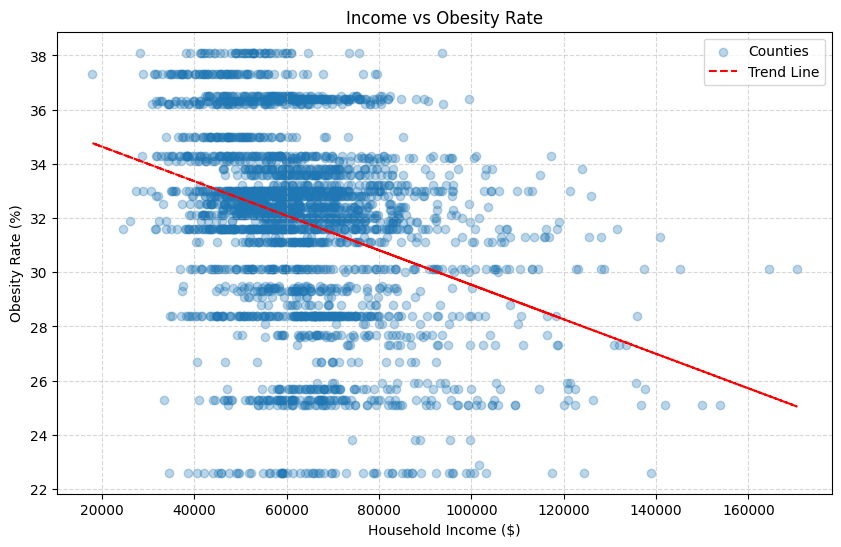

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def visual1():
    # setting up data from previous code
    df_usda = data_parser()
    df_census = web_parser2()

    # converts data to integers, fills any na w/ 0 just in case
    df_usda['FIPS'] = pd.to_numeric(df_usda['FIPS']).fillna(0).astype(int)
    df_census['FIPS'] = pd.to_numeric(df_census['FIPS']).fillna(0).astype(int)

    # merges two dataframes on FIPS column, keeps rows that only exist in both dfs
    merged = pd.merge(df_usda, df_census, on='FIPS', how='inner')

    # gets two columns
    x = merged['Median_Household_Income'] #median income
    y = merged['Adult_Obesity_Percent'] #obesity rate

    # plotting, chose two random sizes for the figure based off what looked good.... lol!
    plt.figure(figsize=(10, 6))

    # scatterplot, made points semi-transparent so it was more readable
    plt.scatter(x, y, alpha=0.3, label='Counties')

    # adding a simple trend line
    m, b = np.polyfit(x, y, 1)

    # this is what actually adds the plot line!
    plt.plot(x, m*x + b, color='red', linestyle='--', label='Trend Line')

    # making graph look nice
    plt.title('Income vs Obesity Rate')
    plt.xlabel('Household Income ($)')
    plt.ylabel('Obesity Rate (%)')
    plt.legend()

    # adds grid to plot so it looks better
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.savefig('visual1.png')
    plt.show()

visual1()

### Visualization 1 Explanation

This scatter plot visualizes the correlation we found in Insight 1. Every dot represents a county. We added a red trend line (using a linear fit) to show the general direction of the data. You can clearly see the downward slope, which illustrates that as families make more money, obesity rates in that county tend to drop.

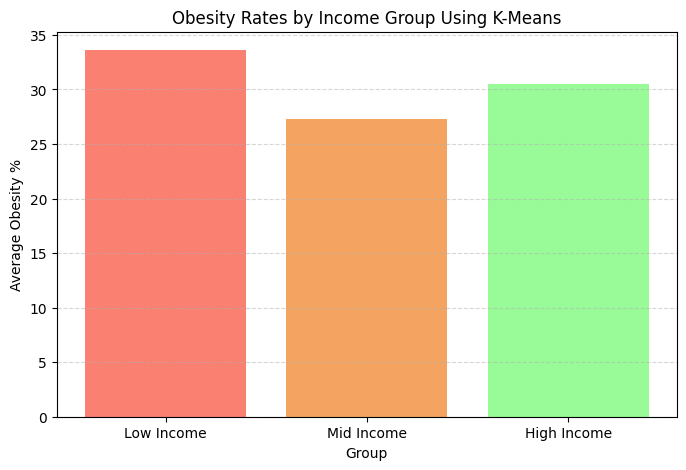

In [12]:
def visual2():
    # need to redo part 1 from last vis to get the labels for plotting
    df_usda = data_parser()
    df_census = web_parser2()

    df_usda['FIPS'] = pd.to_numeric(df_usda['FIPS']).fillna(0).astype(int)
    df_census['FIPS'] = pd.to_numeric(df_census['FIPS']).fillna(0).astype(int)
    merged = pd.merge(df_usda, df_census, on='FIPS', how='inner')

    # select for only income and obesity, drop any NaN just in case
    data = merged[['Median_Household_Income', 'Adult_Obesity_Percent']].dropna()

    # scaling and clustering

    # took from sklearn, standardizes data so mean = 0 and sd = 1
    scaler = StandardScaler()

    # fits ( each value = (x-mean)/sd ) and transforms (applies to whole dataset)
    scaled = scaler.fit_transform(data)

    # creats kMeans clustering model, forms 3 clusters (low, mid, high), runs 10 times for best clustering
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

    # fits (trains model on scaled data) and predicts (assigns each to nearest cluster)
    data['Group'] = kmeans.fit_predict(scaled)

    # groups all rows by cluster label
    # sort by income so index 0 is low income, index 2 is high income
    group_stats = data.groupby('Group')['Median_Household_Income'].mean().sort_values()

    # map readable names to the group numbers
    group_names = {group_stats.index[0]: 'Low Income', group_stats.index[1]: 'Mid Income', group_stats.index[2]: 'High Income'}
    data['Label'] = data['Group'].map(group_names)

    # getting the obesity means for the bar chart
    plot_data = data.groupby('Label')['Adult_Obesity_Percent'].mean()

    # reordering so the bar chart makes sense left to right
    plot_data = plot_data.reindex(['Low Income', 'Mid Income', 'High Income'])

    # plotting
    plt.figure(figsize=(8, 5))
    plt.bar(plot_data.index, plot_data.values, color=['salmon', 'sandybrown', 'palegreen'])


    # making chart easier to understand
    plt.title('Obesity Rates by Income Group Using K-Means')
    plt.xlabel('Group')
    plt.ylabel('Average Obesity %')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.savefig('visual2.png')
    plt.show()

############ Function Call ############
visual2()

### Visualization 2 Explanation

This bar chart displays the three class "profiles" identified by the K-Means Clustering algorithm. The groups were labeled based on their average median household income, showing that lower income is the a risk factor for obesity.


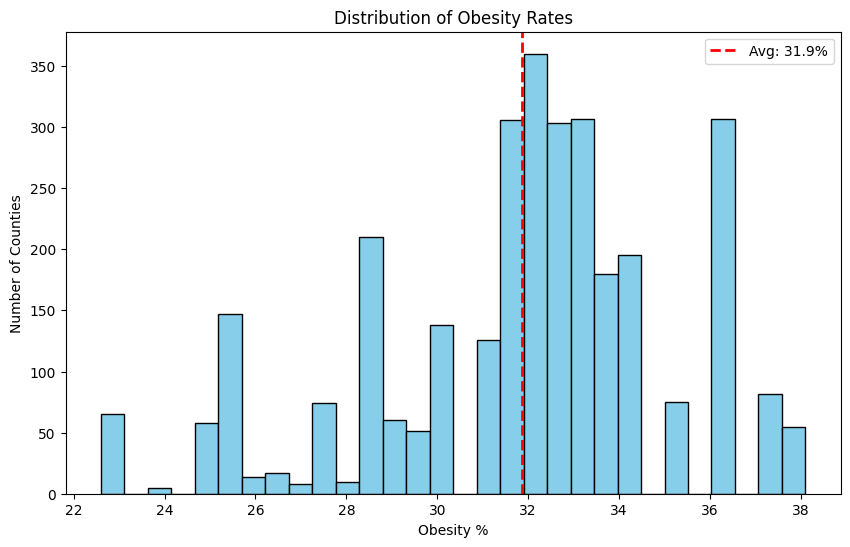

In [13]:
def visual3():

    # getting our dataframe
    df = data_parser()

    # resizing how big figure will be
    plt.figure(figsize=(10, 6))

    # simple histogram to show distribution
    plt.hist(df['Adult_Obesity_Percent'], bins=30, color='skyblue', edgecolor='black')

    # adding a line for the mean
    mean_val = df['Adult_Obesity_Percent'].mean()

    # axisverticalline, draws it at the mean val we calculated
    # formatted the mean to 1 decimal place and added % so it looks nicer
    plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Avg: {mean_val:.1f}%')

    # making chart more readable
    plt.title('Distribution of Obesity Rates')
    plt.xlabel('Obesity %')
    plt.ylabel('Number of Counties')
    plt.legend()

    plt.savefig('visual3.png')
    plt.show()

############ Function Call ############
visual3()

### Visualization 3 Explanation

This histogram shows the distribution of adult obesity rates across all the counties in the dataset. We added a red vertical line to mark the national average. This allows us to see that most counties fall in the middle, but there are more counties with a higher obesity percentage than a lower one.

# Cited Sources

*   https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html
*   https://matplotlib.org/stable/users/index.html
*   https://scikit-learn.org/stable/supervised_learning.html
*   https://scikit-learn.org/stable/modules/clustering.html#k-means
*   https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.quantile.html

